Import required libraries, models, and evaluation metrics.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report


Load the mushroom dataset and display the first five rows.

In [ ]:
from pathlib import Path

dataset_path = Path("data/raw/mushroom.csv")
if not dataset_path.exists():
    dataset_path = Path("../data/raw/mushroom.csv")

df = pd.read_csv(dataset_path)
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


Check the number of rows and columns in the dataset.

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 8124
Number of columns: 23


Display dataset information including data types and non-null values.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

#Display all column names in the dataset.

In [5]:
print(df.columns.tolist())

['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


#Display all column names in the dataset.

In [6]:
df.describe(include="all").T

,count,unique,top,freq
class,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


#Check for missing values in each column and in the entire dataset.

In [7]:
print(df.isnull().sum())
print("")
print("Total missing values:",df.isnull().sum().sum())

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

Total missing values: 0


#Check the number of duplicate rows in the dataset.

In [8]:
print("Number of duplicate rows:",df.duplicated().sum())

Number of duplicate rows: 0


Check unique values in each column and identify constant features.

In [9]:
print(df.nunique().sort_values())

veil-type                    1
class                        2
bruises                      2
gill-attachment              2
gill-spacing                 2
gill-size                    2
stalk-shape                  2
ring-number                  3
cap-surface                  4
veil-color                   4
stalk-surface-below-ring     4
stalk-surface-above-ring     4
ring-type                    5
stalk-root                   5
cap-shape                    6
population                   6
habitat                      7
stalk-color-above-ring       9
stalk-color-below-ring       9
odor                         9
spore-print-color            9
cap-color                   10
gill-color                  12
dtype: int64


Identify columns with only one unique value.

In [10]:
const_features = []
for column in df.columns:
    if df[column].nunique() == 1:
        const_features.append(column)
print("Constant features:", const_features)

Constant features: ['veil-type']


Remove constant features from the dataset.

In [11]:
df = df.drop(columns=const_features)
print("Shape after removing constant feature:", df.shape)

Shape after removing constant feature: (8124, 22)


Analyze class distribution and check for imbalance.

In [12]:
print(df.groupby("class").size())
print("")
print("Percentage distribution:")
print(df.groupby("class").size() / len(df) * 100)

class
e    4208
p    3916
dtype: int64

Percentage distribution:
class
e    51.797144
p    48.202856
dtype: float64


Visualize the distribution of mushroom classes.

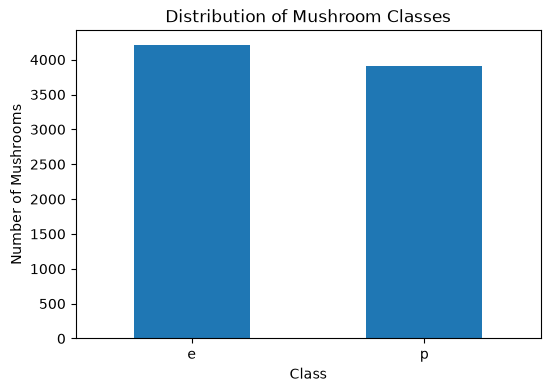

In [13]:
plt.figure(figsize=(6, 4))

df["class"].value_counts().plot(kind="bar")

plt.title("Distribution of Mushroom Classes")
plt.xlabel("Class")
plt.ylabel("Number of Mushrooms")
plt.xticks(rotation=0)

plt.show()

Create cross-tabulations for selected features.

In [14]:
selected_features = [
    "odor",
    "gill-size",
    "gill-color",
    "bruises",
    "ring-type",
    "spore-print-color",
    "population",
    "habitat"
]

for column in selected_features:
    print(f"\n{column}")
    print(pd.crosstab(df[column], df["class"]))


odor
class     e     p
odor             
a       400     0
c         0   192
f         0  2160
l       400     0
m         0    36
n      3408   120
p         0   256
s         0   576
y         0   576

gill-size
class         e     p
gill-size            
b          3920  1692
n           288  2224

gill-color
class         e     p
gill-color           
b             0  1728
e            96     0
g           248   504
h           204   528
k           344    64
n           936   112
o            64     0
p           852   640
r             0    24
u           444    48
w           956   246
y            64    22

bruises
class       e     p
bruises            
f        1456  3292
t        2752   624

ring-type
class         e     p
ring-type            
e          1008  1768
f            48     0
l             0  1296
n             0    36
p          3152   816

spore-print-color
class                 e     p
spore-print-color            
b                    48     0
h             

Visualize feature relationships with class labels.

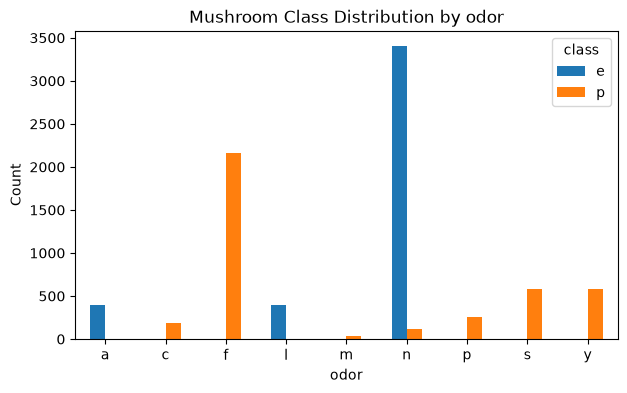

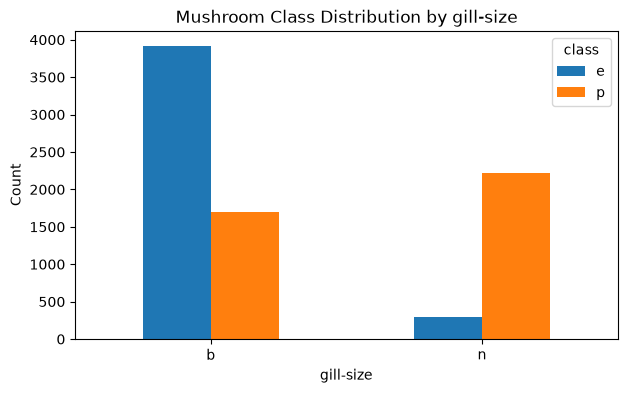

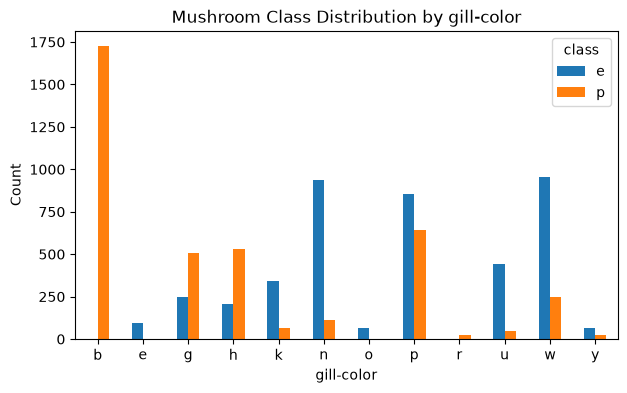

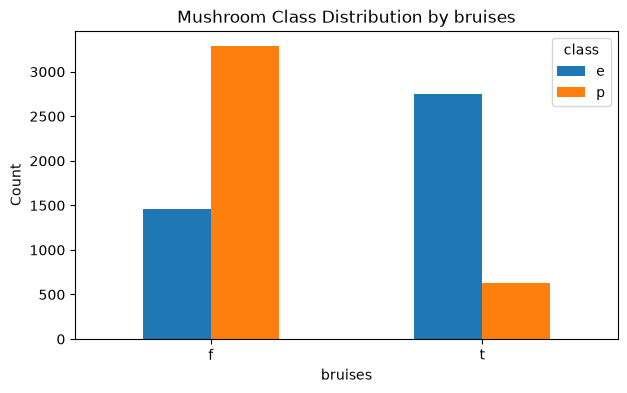

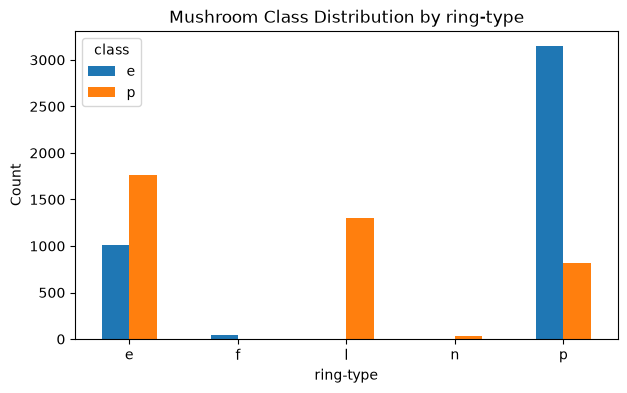

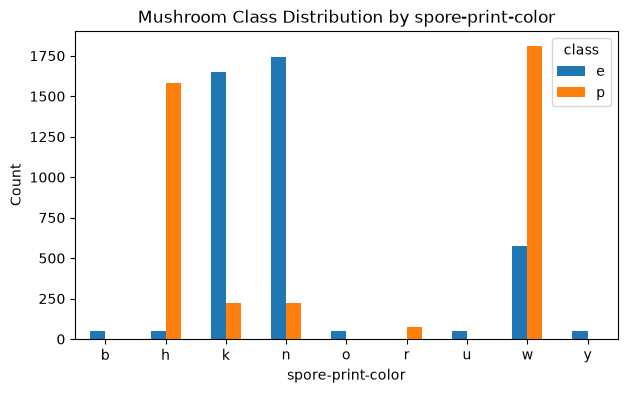

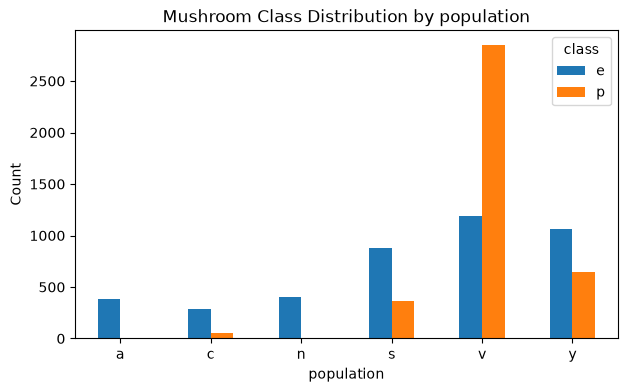

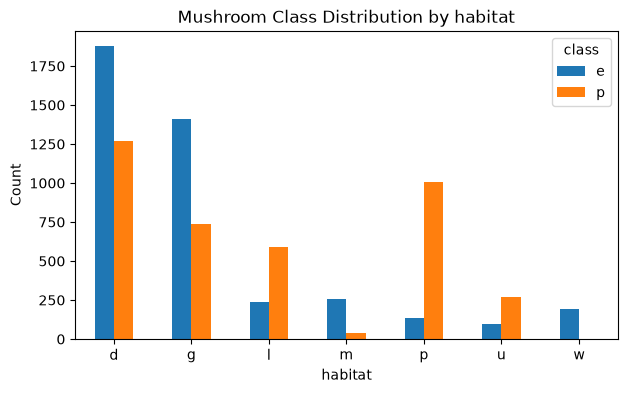

In [15]:
for column in selected_features:
    pd.crosstab(df[column], df["class"]).plot(
        kind="bar",
        figsize=(7, 4)
    )

    plt.title(f"Mushroom Class Distribution by {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=0)

    plt.show()

Separate features and target variable.

In [16]:
"""
X = df.drop("class", axis=1)
y = df["class"]
"""
X = df.drop(["class", "odor", "spore-print-color", "gill-color"], axis=1)
y = df["class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (8124, 18)
Target shape: (8124,)


Encode target variable (edible=1, poisonous=0).

In [17]:
y = y.map({
    "e": 1,
    "p": 0
})

print(y.value_counts())

class
1    4208
0    3916
Name: count, dtype: int64


Split data into training and testing sets.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,

)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6499, 18)
Testing data: (1625, 18)


Encode categorical features using one-hot encoding.

In [19]:
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (6499, 86)
Encoded testing shape: (1625, 86)


Display final number of encoded features.

In [20]:
print("Number of encoded features:", X_train_encoded.shape[1])

Number of encoded features: 86


Initialize machine learning models.

In [21]:

"""models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier()
}"""

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=20, max_depth=4, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=35)
}

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_encoded,
        y_train,
        cv=cv,
        scoring="accuracy"
    )
    cv_results[name] = scores

cv_df = pd.DataFrame({
    "Model": list(cv_results.keys()),
    "CV Accuracy Mean": [scores.mean() for scores in cv_results.values()],
    "CV Accuracy Std": [scores.std() for scores in cv_results.values()]
}).sort_values("CV Accuracy Mean", ascending=False)

cv_df

,Model,CV Accuracy Mean,CV Accuracy Std
3,KNN,0.994921,0.003394
0,Logistic Regression,0.992922,0.003419
1,Decision Tree,0.963072,0.003602
2,Random Forest,0.956455,0.004707


Train all models and evaluate their performance.

In [23]:
results = []

for name, model in models.items():

    model.fit(X_train_encoded, y_train)

    y_pred = model.predict(X_test_encoded)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,KNN,0.996308,0.998808,0.994069,0.996433
0,Logistic Regression,0.990769,0.996403,0.985765,0.991055
1,Decision Tree,0.962462,0.967703,0.959668,0.963669
2,Random Forest,0.951385,0.916122,0.997628,0.955139


Plot initial model performance comparison.

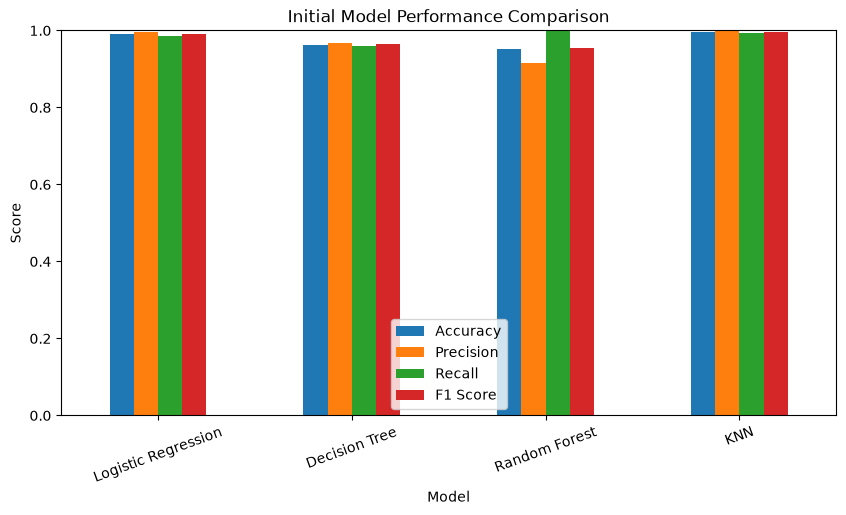

In [24]:
results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Initial Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.show()

Perform cross-validation for model evaluation.

In [25]:
cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_encoded,
        y_train,
        cv=5,
        scoring="f1"
    )

    cv_results.append({
        "Model": name,
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

cv_df.sort_values(
    by="Mean CV F1",
    ascending=False
)

,Model,Mean CV F1,Std CV F1
3,KNN,0.995529,0.001638
0,Logistic Regression,0.992540,0.002842
1,Decision Tree,0.963411,0.008146
2,Random Forest,0.958544,0.005651


Hyperparameter tuning for Random Forest using GridSearchCV.

In [26]:
rf = RandomForestClassifier(random_state=42)

"""rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}"""
rf_params = {
    "n_estimators": [10, 20],
    "max_depth": [3, 4, 5],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train_encoded, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best CV F1 Score:", rf_grid.best_score_)

Best parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 20}
Best CV F1 Score: 0.9827999862900464


Hyperparameter tuning for Decision Tree using GridSearchCV.

In [27]:
"""dt = DecisionTreeClassifier(random_state=42)

dt_params = {
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(
    dt,
    dt_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(X_train_encoded, y_train)"""
dt = DecisionTreeClassifier(random_state=42)

dt_params = {
    "max_depth": [2, 3],
    "min_samples_split": [10, 20],
    "min_samples_leaf": [5, 10]
}

dt_grid = GridSearchCV(
    dt,
    dt_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(X_train_encoded, y_train)

print("Best parameters:", dt_grid.best_params_)
print("Best CV F1 Score:", dt_grid.best_score_)

Best parameters: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 10}
Best CV F1 Score: 0.9489349952001629


Evaluate best Random Forest model on test set.

In [28]:
best_rf = rf_grid.best_estimator_

rf_pred = best_rf.predict(X_test_encoded)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

Random Forest
Accuracy: 0.9766153846153847
Precision: 0.969661610268378
Recall: 0.9857651245551602
F1 Score: 0.9776470588235294


Evaluate best Decision Tree model on test set.

In [29]:
best_dt = dt_grid.best_estimator_

dt_pred = best_dt.predict(X_test_encoded)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1 Score:", f1_score(y_test, dt_pred))

Decision Tree
Accuracy: 0.9458461538461539
Precision: 0.9314285714285714
Recall: 0.966785290628707
F1 Score: 0.9487776484284052


Print detailed classification report.

In [30]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       782
           1       0.97      0.99      0.98       843

    accuracy                           0.98      1625
   macro avg       0.98      0.98      0.98      1625
weighted avg       0.98      0.98      0.98      1625



Plot confusion matrix for final model.

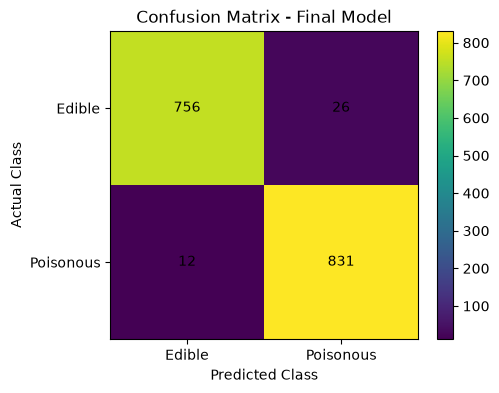

In [31]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5, 4))

plt.imshow(cm)

plt.title("Confusion Matrix - Final Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks([0, 1], ["Edible", "Poisonous"])
plt.yticks([0, 1], ["Edible", "Poisonous"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()

plt.show()

Compare performance of all models.

In [32]:
final_results = []

for name, model in models.items():

    model.fit(X_train_encoded, y_train)
    pred = model.predict(X_test_encoded)

    final_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

# Add tuned Random Forest
final_results.append({
    "Model": "Tuned Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1 Score": f1_score(y_test, rf_pred)
})

# Add tuned Decision Tree
final_results.append({
    "Model": "Tuned Decision Tree",
    "Accuracy": accuracy_score(y_test, dt_pred),
    "Precision": precision_score(y_test, dt_pred),
    "Recall": recall_score(y_test, dt_pred),
    "F1 Score": f1_score(y_test, dt_pred)
})

final_results_df = pd.DataFrame(final_results)

final_results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,KNN,0.996308,0.998808,0.994069,0.996433
0,Logistic Regression,0.990769,0.996403,0.985765,0.991055
4,Tuned Random Forest,0.976615,0.969662,0.985765,0.977647
1,Decision Tree,0.962462,0.967703,0.959668,0.963669
2,Random Forest,0.951385,0.916122,0.997628,0.955139
5,Tuned Decision Tree,0.945846,0.931429,0.966785,0.948778


Extract and analyze feature importance from best model.

In [33]:
feature_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
36,stalk-surface-above-ring_k,0.132031
72,ring-type_p,0.092769
27,gill-size_n,0.086469
26,gill-size_b,0.076769
37,stalk-surface-above-ring_s,0.059705
25,gill-spacing_w,0.054564
40,stalk-surface-below-ring_k,0.048128
77,population_v,0.040794
24,gill-spacing_c,0.036684
41,stalk-surface-below-ring_s,0.034022


Visualize top 15 most important features.

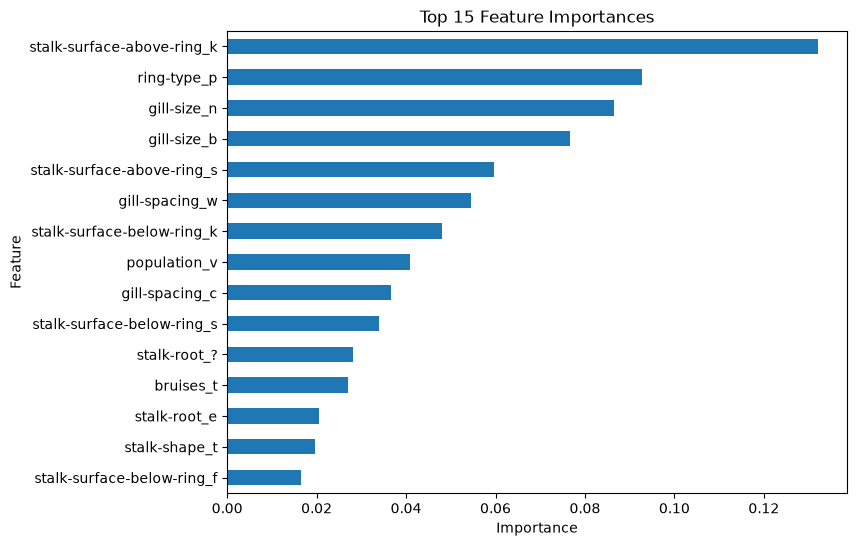

In [34]:
feature_importance.head(15).sort_values(
    by="Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8, 6),
    legend=False
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")

plt.show()

Make prediction on a new mushroom sample.

In [35]:
new_mushroom = pd.DataFrame([{
    "cap-shape": "x",
    "cap-surface": "s",
    "cap-color": "n",
    "bruises": "t",
    "odor": "n",
    "gill-attachment": "f",
    "gill-spacing": "c",
    "gill-size": "b",
    "gill-color": "k",
    "stalk-shape": "e",
    "stalk-root": "e",
    "stalk-surface-above-ring": "s",
    "stalk-surface-below-ring": "s",
    "stalk-color-above-ring": "w",
    "stalk-color-below-ring": "w",
    "veil-color": "w",
    "ring-number": "o",
    "ring-type": "p",
    "spore-print-color": "n",
    "population": "s",
    "habitat": "u"
}])

new_mushroom_encoded = pd.get_dummies(new_mushroom)

new_mushroom_encoded = new_mushroom_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

new_mushroom_encoded

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0,0,0,0,0,True,0,0,True,0,...,True,0,0,0,0,0,0,0,True,0


Output the final prediction result.

In [36]:
prediction = best_rf.predict(new_mushroom_encoded)

if prediction[0] == 1:
    print("Prediction: Edible")
else:
    print("Prediction: Poisonous")

Prediction: Edible
